In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay, precision_recall_curve
)
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings("ignore")

## 1. Load Data & Quick Look

In [5]:
df = pd.read_csv("ev battery_failure prediction Dataset.csv")
print(df.shape) # (20000, 70)
print(df["battery_failure"].value_counts())

(20000, 70)
battery_failure
0    18616
1     1384
Name: count, dtype: int64


In [6]:

df.isnull().sum().sort_values(ascending=False).head(10)

fast_charge_ratio         988
average_speed             984
manufacturing_year        982
home_charging_ratio       980
sensor_fault_count        968
state_of_charge           964
charging_interruptions    964
state_of_health           956
capacity_loss_percent     956
slow_charge_ratio         948
dtype: int64

## 2. Data Understanding – Visual EDA

### 2.1 Target Class Imbalance (Very Important Chart)

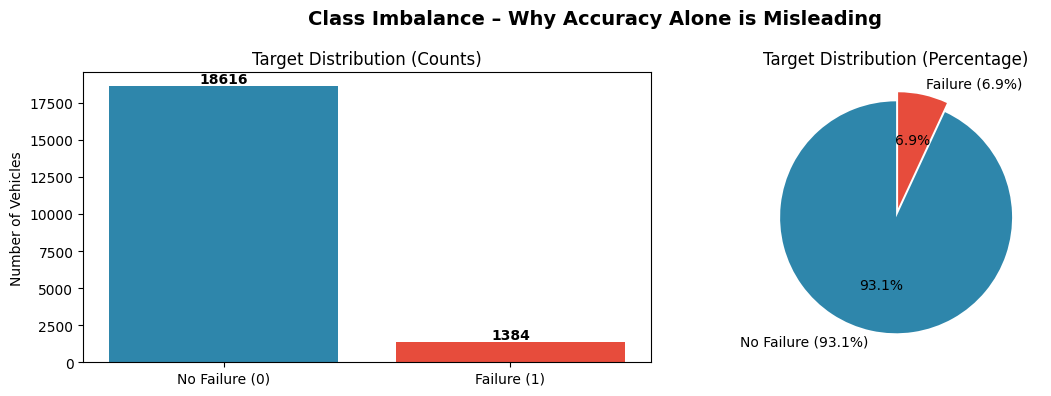

Key talking point: A model that always predicts 'No Failure' gets ~93% accuracy but catches ZERO failures.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df["battery_failure"].value_counts()
axes[0].bar(["No Failure (0)", "Failure (1)"], counts.values, color=["#2E86AB", "#E74C3C"])
axes[0].set_title("Target Distribution (Counts)")
axes[0].set_ylabel("Number of Vehicles")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha="center", fontweight="bold")

# Percentage pie
axes[1].pie(counts.values, labels=["No Failure (93.1%)", "Failure (6.9%)"],
            colors=["#2E86AB", "#E74C3C"], autopct="%1.1f%%", startangle=90,
            explode=(0, 0.08))
axes[1].set_title("Target Distribution (Percentage)")

plt.suptitle("Class Imbalance – Why Accuracy Alone is Misleading", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Key talking point: A model that always predicts 'No Failure' gets ~93% accuracy but catches ZERO failures.")

### 2.2 Missing Values Overview

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_pct

fast_charge_ratio        4.94
average_speed            4.92
manufacturing_year       4.91
home_charging_ratio      4.90
sensor_fault_count       4.84
                         ... 
battery_manufacturer     3.09
pack_voltage             3.09
average_charging_time    3.07
remaining_capacity       3.07
dust_exposure            3.05
Length: 67, dtype: float64

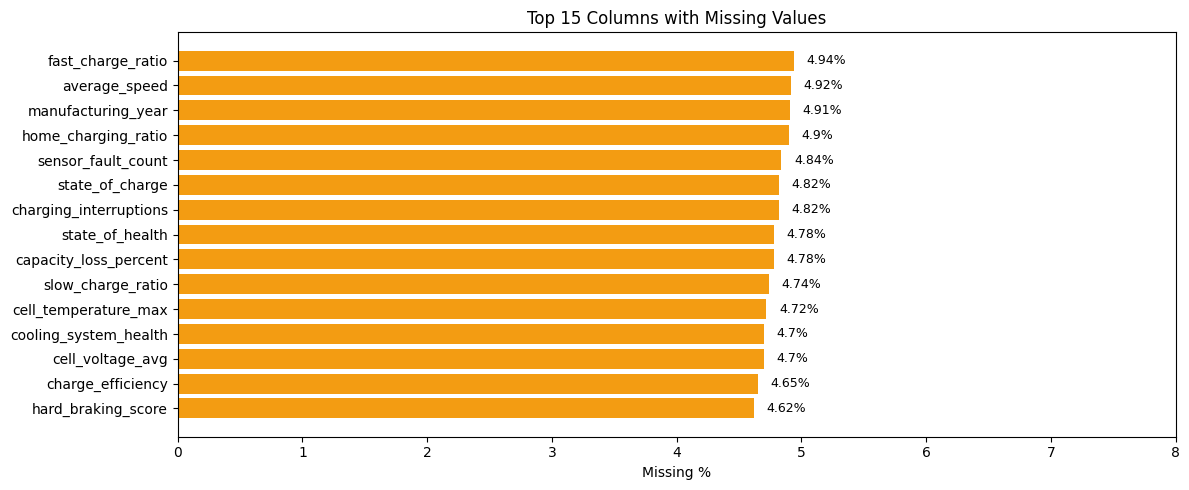

Total columns with missing values: 67 out of 70


In [10]:

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing_pct.head(15).index[::-1], missing_pct.head(15).values[::-1], color="#F39C12")
ax.set_xlabel("Missing %")
ax.set_title("Top 15 Columns with Missing Values")
ax.set_xlim(0, 8)
for bar, val in zip(bars, missing_pct.head(15).values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total columns with missing values: {(df.isnull().sum() > 0).sum()} out of {df.shape[1]}")

### 2.3 Key Numeric Distributions (Health & Temperature)

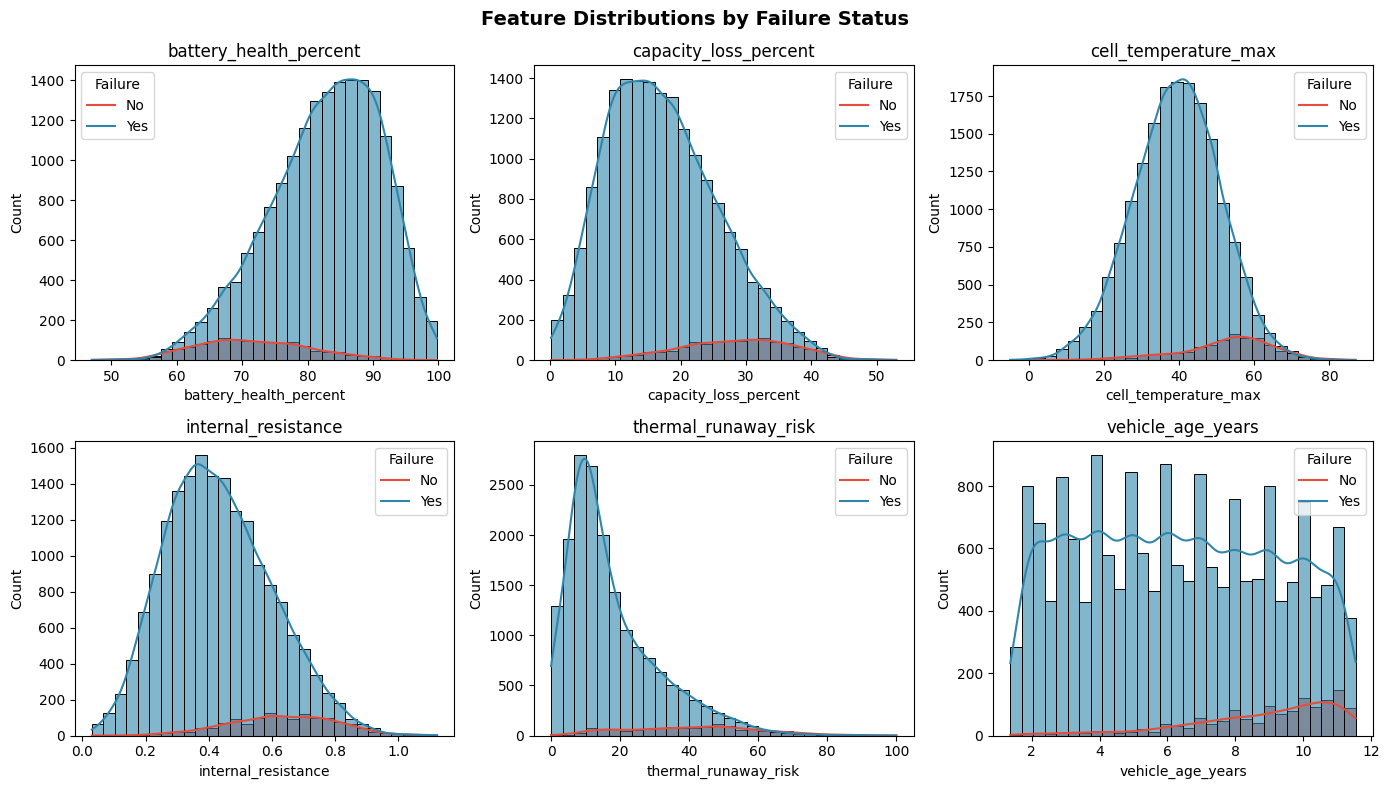

In [11]:
key_cols = ["battery_health_percent", "capacity_loss_percent",
            "cell_temperature_max", "internal_resistance",
            "thermal_runaway_risk", "vehicle_age_years"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    if col in df.columns:
        sns.histplot(data=df, x=col, hue="battery_failure", bins=30,
                     palette={0: "#2E86AB", 1: "#E74C3C"}, ax=axes[i], kde=True, alpha=0.6)
        axes[i].set_title(col)
        axes[i].legend(title="Failure", labels=["No", "Yes"])

plt.suptitle("Feature Distributions by Failure Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.4 Box Plots – Failed vs Healthy Batteries

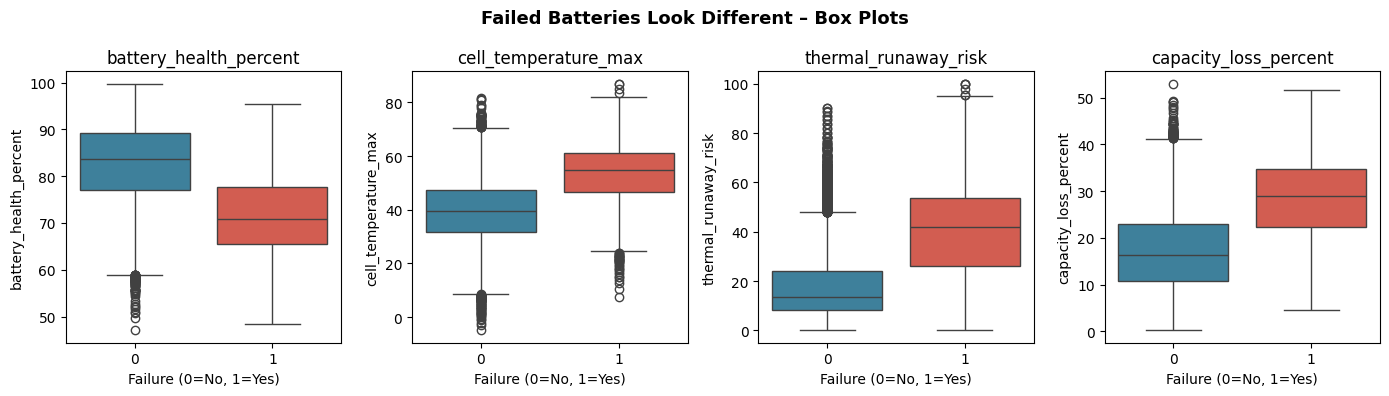

Talking point: Failed batteries tend to have lower health %, higher temperature, higher thermal risk and more capacity loss.


In [12]:
box_cols = ["battery_health_percent", "cell_temperature_max",
            "thermal_runaway_risk", "capacity_loss_percent"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(box_cols):
    if col in df.columns:
        sns.boxplot(data=df, x="battery_failure", y=col,
                    palette={"0": "#2E86AB", "1": "#E74C3C"}, ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel("Failure (0=No, 1=Yes)")

plt.suptitle("Failed Batteries Look Different – Box Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Talking point: Failed batteries tend to have lower health %, higher temperature, higher thermal risk and more capacity loss.")

## 3. Data Cleaning

remove ID columns

In [13]:
data = df.drop(columns=["vehicle_id", "battery_serial"], errors="ignore")
y = data["battery_failure"]
X = data.drop(columns=["battery_failure"])

fill missing numbers with the median, fill missing text with
the most common value

In [14]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object","string"]).columns.tolist()

X[numeric_cols] = SimpleImputer(strategy="median").fit_transform(X[numeric_cols])
if categorical_cols:
    X[categorical_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[categorical_cols])

 turn text categories into numbers

In [15]:
# Encode categories
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Categoricals encoded. Shape:", X.shape)

Categoricals encoded. Shape: (20000, 67)


## 4. Feature Engineering

In [16]:
X["capacity_ratio"] = X["remaining_capacity"] / (X["battery_capacity_kwh"] + 1e-6)
X["temp_spread"] = X["cell_temperature_max"] - X["cell_temperature_avg"]
X["fast_vs_slow"] = X["fast_charge_ratio"] - X["slow_charge_ratio"]
X["km_per_year"] = X["odometer_km"] / (X["vehicle_age_years"] + 0.1)

stress_cols = [c for c in ["battery_stress_index", "driving_stress_score",
                           "aggressive_acceleration_score", "hard_braking_score"] if c in X.columns]
if stress_cols:
    X["combined_stress"] = X[stress_cols].mean(axis=1)

print("New features added. Shape now:", X.shape)

New features added. Shape now: (20000, 72)


## 5. Correlation Heatmap (Top Features vs Target)

In [17]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)
top_corr_feats = corr_target.head(12).index.tolist()

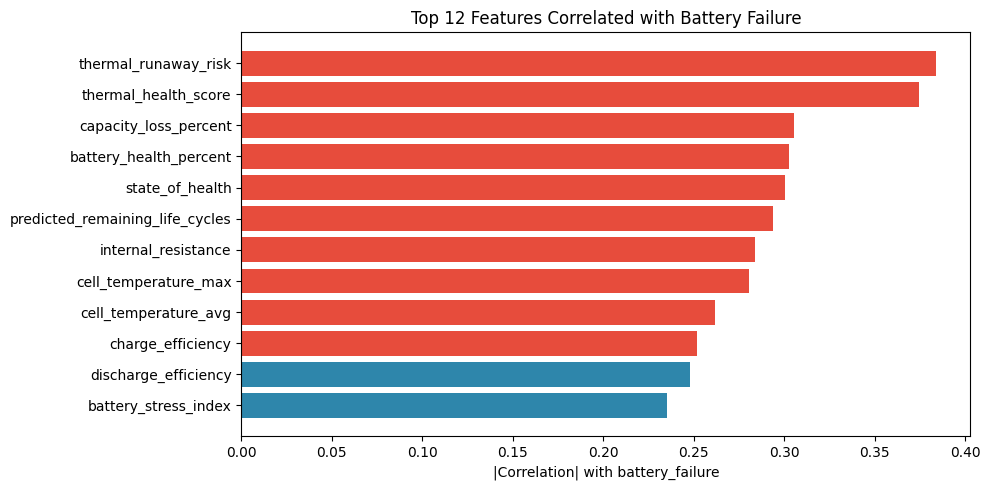

Strongest signals: thermal risk, thermal health, capacity loss, battery health, temperature.


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E74C3C" if v > 0.25 else "#2E86AB" for v in corr_target.head(12).values]
bars = ax.barh(corr_target.head(12).index[::-1], corr_target.head(12).values[::-1], color=colors[::-1])
ax.set_xlabel("|Correlation| with battery_failure")
ax.set_title("Top 12 Features Correlated with Battery Failure")
plt.tight_layout()
plt.show()

print("Strongest signals: thermal risk, thermal health, capacity loss, battery health, temperature.")

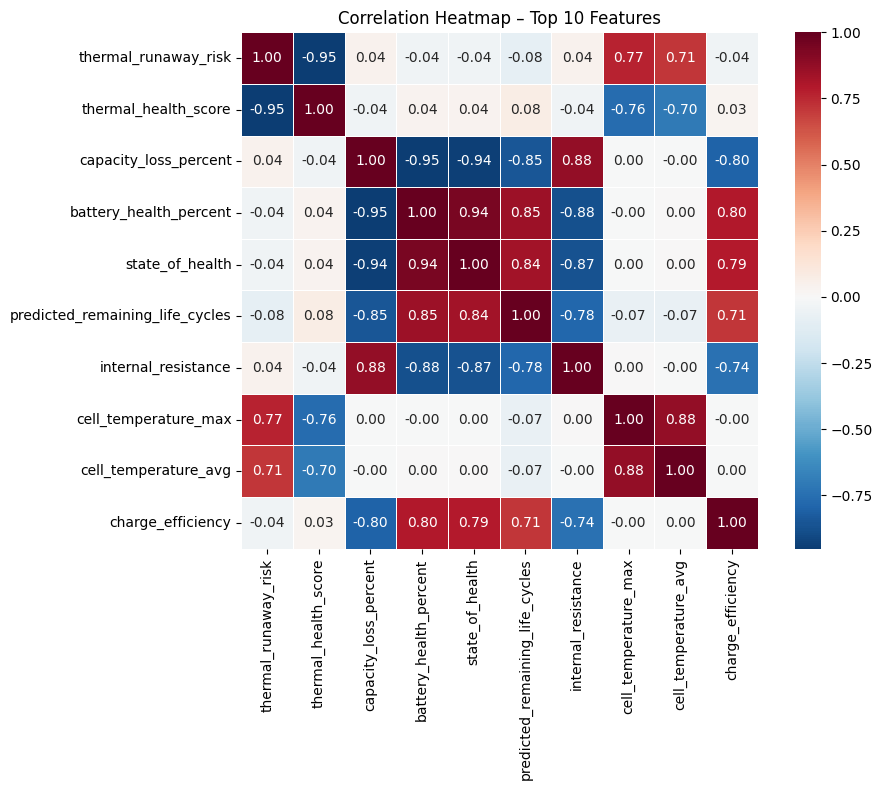

Talking point: Some features are highly correlated (e.g. health % and capacity loss). Trees handle this better than linear models.


In [19]:
# Heatmap of top features among themselves
top_for_heat = corr_target.head(10).index.tolist()
corr_matrix = X[top_for_heat].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap – Top 10 Features")
plt.tight_layout()
plt.show()

print("Talking point: Some features are highly correlated (e.g. health % and capacity loss). Trees handle this better than linear models.")

## 6. Feature Selection + Train-Test Split

In [20]:
selector = SelectKBest(score_func=f_classif, k=30)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()
X_final = pd.DataFrame(X_selected, columns=selected_features)

print(f"Selected {len(selected_features)} features out of {X.shape[1]}")
print("Selected:", selected_features[:10], "...")

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train failure rate: {y_train.mean():.4f}  |  Test failure rate: {y_test.mean():.4f}")

Selected 30 features out of 72
Selected: ['manufacturing_year', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_health', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency'] ...

Train: (16000, 30)  |  Test: (4000, 30)
Train failure rate: 0.0692  |  Test failure rate: 0.0693


## 7. Train Models

In [21]:
models = {}
preds = {}
probs = {}

In [22]:
# Logistic Regression

lr = LogisticRegression(
    class_weight= "balanced",
    max_iter= 1000,
    random_state= 42, 
    n_jobs= -1
)

lr.fit(X_train_scaled, y_train)

models['Logistic Regression'] = lr
preds['Logistic Regression'] = lr.predict(X_test_scaled)
probs['Logistic Regression'] = lr.predict_proba(X_test_scaled)[:,1]

In [23]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators= 200,
    max_depth= 12,
    class_weight= "balanced",
    random_state= 42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

models["Random Forest"] = rf
preds["Random Forest"] = rf.predict(X_test)
probs["Random Forest"] = rf.predict_proba(X_test)[:,1]

In [24]:
# Gradient Boosting

gb = GradientBoostingClassifier(
    n_estimators= 150,
    max_depth= 5, 
    learning_rate= 0.1,
    random_state= 42
)

gb.fit(X_train, y_train)

models["Gradient Boosting"] = gb
preds["Gradient Boosting"] = gb.predict(X_test)
probs["Gradient Boosting"] = gb.predict_proba(X_test)[:, 1] 

In [26]:
# XGBoost

scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.08,
    scale_pos_weight = scale,
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)
xgb.fit(X_train, y_train)

models["XGBoost"] = xgb
preds["XGBoost"] = xgb.predict(X_test)
probs["XGBoost"] = xgb.predict_proba(X_test)[:, 1]

In [27]:
print("Models trained:", list(models.keys()))

Models trained: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 8. Evaluation – Metrics Table

In [28]:
results = []
for name in models:
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds[name]), 4),
        "Precision": round(precision_score(y_test, preds[name], zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds[name], zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, preds[name], zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs[name]), 4)
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
            XGBoost    0.9597     0.6667  0.8375    0.7424   0.9799
  Gradient Boosting    0.9640     0.8093  0.6282    0.7073   0.9814
Logistic Regression    0.9355     0.5187  0.9531    0.6718   0.9847
      Random Forest    0.9453     0.6028  0.6137    0.6082   0.9651


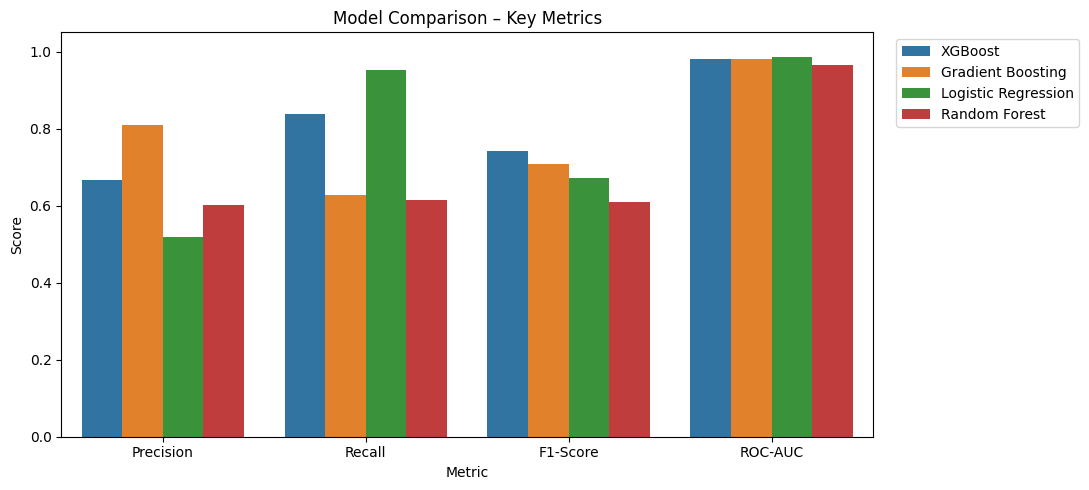


Talking points:
- XGBoost usually best F1 balance
- Logistic Regression has highest Recall (catches almost all failures) but more false alarms
- Choose model based on business cost of FN vs FP


In [29]:

# Visual comparison
metrics_to_plot = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = results_df.melt(id_vars="Model", value_vars=metrics_to_plot,
                          var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Model Comparison – Key Metrics")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nTalking points:")
print("- XGBoost usually best F1 balance")
print("- Logistic Regression has highest Recall (catches almost all failures) but more false alarms")
print("- Choose model based on business cost of FN vs FP")

## 9. Confusion Matrices 

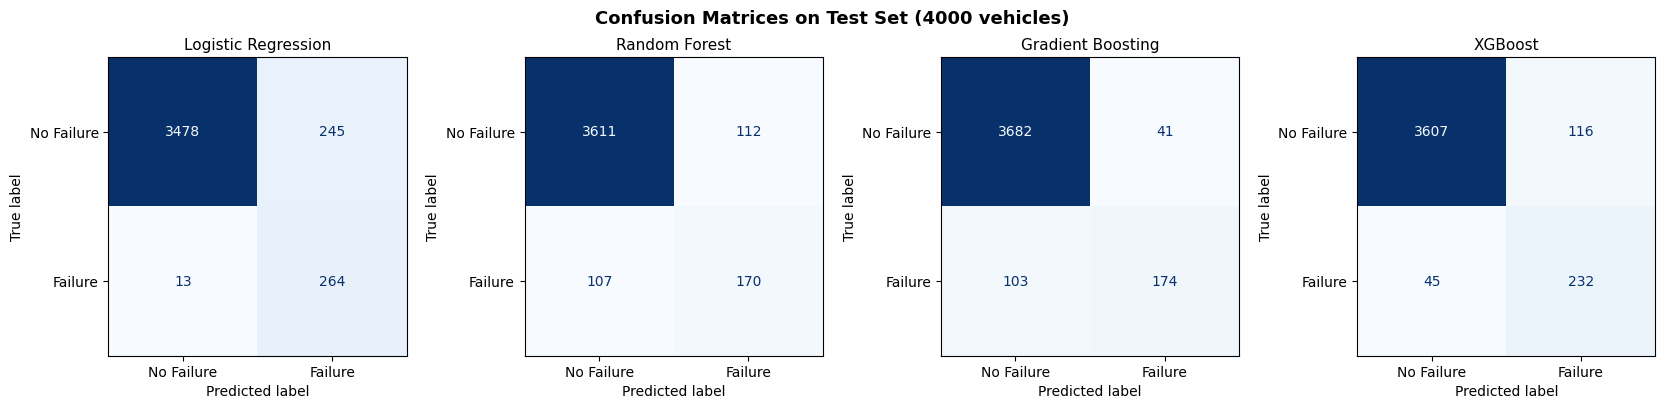

In [ ]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(4.2 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, models.keys()):
    
    cm = confusion_matrix(y_test, preds[name])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Failure", "Failure"]
    )
    
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11)

plt.suptitle("Confusion Matrices on Test Set (4000 vehicles)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

'
I analyzed the confusion matrices to understand the types of errors made by each model. Logistic Regression had the highest recall at 95.31%, meaning it missed only 13 actual failures, but it generated 245 false positives. Gradient Boosting had the highest precision, but missed 103 failures. XGBoost provided a better balance, detecting 232 of 277 actual failures while producing 116 false positives, resulting in an F1-score of 74.24%. Therefore, I selected XGBoost as the overall model, while recognizing that Logistic Regression could be preferable if minimizing missed failures were the absolute priority.
'

## 10. ROC Curves

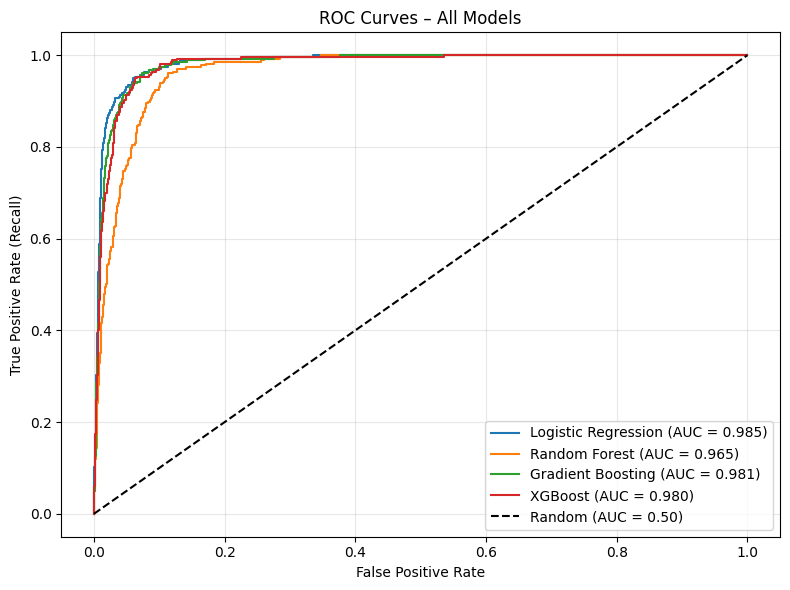

In [35]:
plt.figure(figsize=(8, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    auc = roc_auc_score(y_test, probs[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves – All Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Precision-Recall Curve (Better for Imbalanced Data)

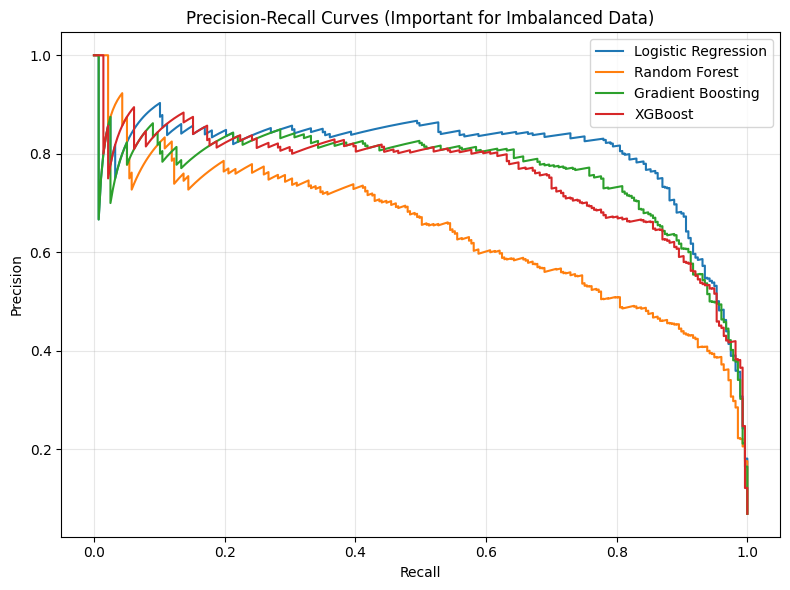

Talking point: PR curves are more informative than ROC when the positive class is rare.


In [36]:
plt.figure(figsize=(8, 6))
for name in models:
    precision, recall, _ = precision_recall_curve(y_test, probs[name])
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Important for Imbalanced Data)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Talking point: PR curves are more informative than ROC when the positive class is rare.")

## 12. Feature Importance (What the Model Learned)

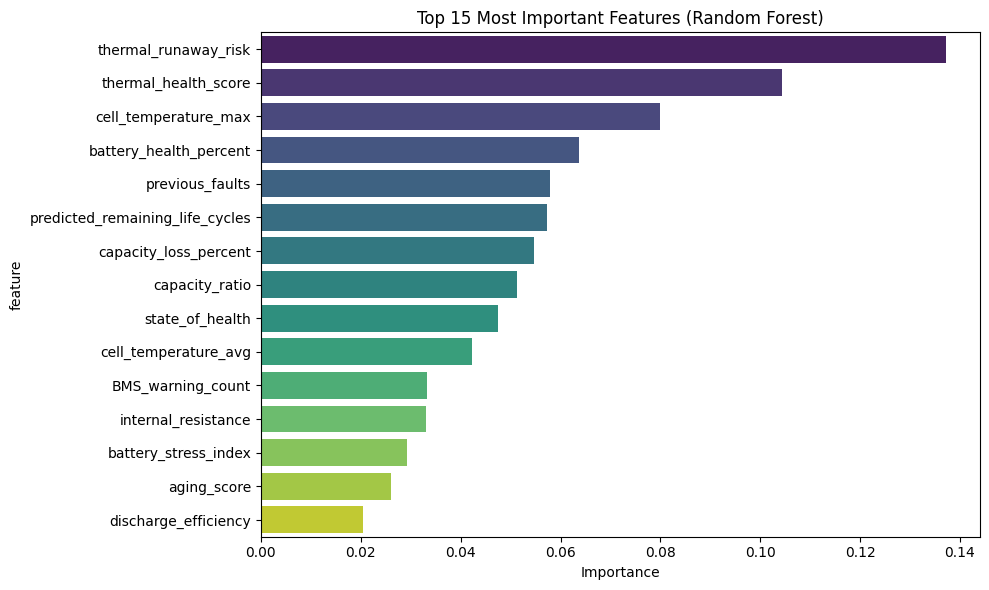

Top drivers of failure prediction:
                        feature  importance
           thermal_runaway_risk    0.137151
           thermal_health_score    0.104353
           cell_temperature_max    0.080001
         battery_health_percent    0.063798
                previous_faults    0.057919
predicted_remaining_life_cycles    0.057262
          capacity_loss_percent    0.054684
                 capacity_ratio    0.051371

Talking point: Thermal risk, temperature and battery health dominate – matches domain knowledge.


In [37]:
imp_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": models["Random Forest"].feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), x="importance", y="feature", palette="viridis")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top drivers of failure prediction:")
print(imp_df.head(8).to_string(index=False))
print("\nTalking point: Thermal risk, temperature and battery health dominate – matches domain knowledge.")

***

I'm selecting XGBoost because it provided the best overall balance between precision and recall. It achieved the highest F1-score of 74.24%, with 83.75% recall and 66.67% precision. Logistic Regression had higher recall and ROC-AUC, while Gradient Boosting had higher precision, but both had a lower F1-score. Since battery failure detection requires both catching failures and controlling false alarms, XGBoost was the most balanced model for my objective.

***

In [38]:
import pickle

model_package = {
    "model": xgb,
    "scaler": scaler,
    "selected_features": selected_features
}

with open("battery_failure_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Model saved successfully!")

Model saved successfully!


In [39]:
# ============================================================
# TEST TRAINED XGBOOST MODEL WITH A NEW SAMPLE
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. ENTER TEST VALUES
# ------------------------------------------------------------

test_data = {

    # Vehicle information
    "manufacturing_year": 2022,
    "odometer_km": 45000,
    "vehicle_age_years": 3,
    "cycle_count": 850,

    # Battery information
    "battery_health_percent": 82,
    "state_of_health": 80,
    "capacity_loss_percent": 18,
    "remaining_capacity": 65,
    "battery_capacity_kwh": 80,
    "predicted_remaining_life_cycles": 450,
    "aging_score": 35,
    "previous_faults": 2,

    # Thermal information
    "cell_temperature_max": 45,
    "cell_temperature_avg": 32,
    "internal_resistance": 0.025,
    "thermal_runaway_risk": 0.75,
    "thermal_health_score": 68,
    "temperature_variance": 5.2,
    "dust_exposure": 0.30,
    "cooling_system_health": 75,

    # Electrical information
    "charge_efficiency": 91,
    "discharge_efficiency": 93,
    "voltage_imbalance": 0.04,
    "BMS_warning_count": 3,
    "abnormal_voltage_events": 2,
    "maintenance_score": 72,

    # Driving / stress
    "battery_stress_index": 45,
    "driving_stress_score": 50,
    "aggressive_acceleration_score": 35,
    "hard_braking_score": 30
}


# ------------------------------------------------------------
# 2. CONVERT TO DATAFRAME
# ------------------------------------------------------------

test_df = pd.DataFrame([test_data])


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING
# SAME AS TRAINING
# ------------------------------------------------------------

# Capacity ratio
test_df["capacity_ratio"] = (
    test_df["remaining_capacity"]
    /
    (test_df["battery_capacity_kwh"] + 1e-6)
)


# Temperature spread
test_df["temp_spread"] = (
    test_df["cell_temperature_max"]
    -
    test_df["cell_temperature_avg"]
)


# Kilometers per year
test_df["km_per_year"] = (
    test_df["odometer_km"]
    /
    (test_df["vehicle_age_years"] + 0.1)
)


# Combined stress
stress_cols = [
    "battery_stress_index",
    "driving_stress_score",
    "aggressive_acceleration_score",
    "hard_braking_score"
]

test_df["combined_stress"] = (
    test_df[stress_cols].mean(axis=1)
)


# ------------------------------------------------------------
# 4. SELECT SAME FEATURES USED BY MODEL
# ------------------------------------------------------------

test_final = test_df[selected_features]


# ------------------------------------------------------------
# 5. MAKE PREDICTION
# IMPORTANT:
# XGBoost WAS TRAINED ON UNSCALED DATA
# ------------------------------------------------------------

prediction = xgb.predict(test_final)[0]


# ------------------------------------------------------------
# 6. GET FAILURE PROBABILITY
# ------------------------------------------------------------

failure_probability = (
    xgb.predict_proba(test_final)[0][1]
)


# ------------------------------------------------------------
# 7. DISPLAY RESULT
# ------------------------------------------------------------

print("=" * 50)
print("       EV BATTERY FAILURE PREDICTION")
print("=" * 50)

print(
    f"\nFailure Probability: "
    f"{failure_probability * 100:.2f}%"
)


if prediction == 1:

    print("Prediction: BATTERY FAILURE RISK")

else:

    print("Prediction: BATTERY IS HEALTHY")


print("\nCalculated Features:")
print(
    f"Capacity Ratio : "
    f"{test_df['capacity_ratio'].iloc[0]:.4f}"
)

print(
    f"Temperature Spread : "
    f"{test_df['temp_spread'].iloc[0]:.2f}"
)

print(
    f"KM per Year : "
    f"{test_df['km_per_year'].iloc[0]:.2f}"
)

print(
    f"Combined Stress : "
    f"{test_df['combined_stress'].iloc[0]:.2f}"
)

print("=" * 50)

       EV BATTERY FAILURE PREDICTION

Failure Probability: 0.19%
Prediction: BATTERY IS HEALTHY

Calculated Features:
Capacity Ratio : 0.8125
Temperature Spread : 13.00
KM per Year : 14516.13
Combined Stress : 40.00


In [40]:
# ============================================================
# TEST DIFFERENT BATTERY CONDITIONS
# ============================================================

def test_battery(test_data):

    test_df = pd.DataFrame([test_data])

    # Feature engineering
    test_df["capacity_ratio"] = (
        test_df["remaining_capacity"]
        /
        (test_df["battery_capacity_kwh"] + 1e-6)
    )

    test_df["temp_spread"] = (
        test_df["cell_temperature_max"]
        -
        test_df["cell_temperature_avg"]
    )

    test_df["km_per_year"] = (
        test_df["odometer_km"]
        /
        (test_df["vehicle_age_years"] + 0.1)
    )

    stress_cols = [
        "battery_stress_index",
        "driving_stress_score",
        "aggressive_acceleration_score",
        "hard_braking_score"
    ]

    test_df["combined_stress"] = (
        test_df[stress_cols].mean(axis=1)
    )

    # Select exact model features
    test_final = test_df[selected_features]

    # XGBoost prediction
    prediction = xgb.predict(test_final)[0]

    probability = xgb.predict_proba(test_final)[0][1]

    return prediction, probability


# ============================================================
# HEALTHY BATTERY
# ============================================================

healthy_battery = {
    "manufacturing_year": 2025,
    "odometer_km": 15000,
    "vehicle_age_years": 1,
    "cycle_count": 250,

    "battery_health_percent": 97,
    "state_of_health": 96,
    "capacity_loss_percent": 3,
    "remaining_capacity": 77,
    "battery_capacity_kwh": 80,
    "predicted_remaining_life_cycles": 1800,
    "aging_score": 5,
    "previous_faults": 0,

    "cell_temperature_max": 35,
    "cell_temperature_avg": 28,
    "internal_resistance": 0.010,
    "thermal_runaway_risk": 0.05,
    "thermal_health_score": 95,
    "temperature_variance": 1.5,
    "dust_exposure": 0.05,
    "cooling_system_health": 95,

    "charge_efficiency": 98,
    "discharge_efficiency": 98,
    "voltage_imbalance": 0.01,
    "BMS_warning_count": 0,
    "abnormal_voltage_events": 0,
    "maintenance_score": 95,

    "battery_stress_index": 10,
    "driving_stress_score": 10,
    "aggressive_acceleration_score": 5,
    "hard_braking_score": 5
}


# ============================================================
# MODERATE BATTERY
# ============================================================

moderate_battery = healthy_battery.copy()

moderate_battery.update({
    "battery_health_percent": 80,
    "state_of_health": 78,
    "capacity_loss_percent": 22,
    "remaining_capacity": 62,
    "predicted_remaining_life_cycles": 400,
    "aging_score": 45,
    "previous_faults": 2,

    "cell_temperature_max": 48,
    "cell_temperature_avg": 32,
    "internal_resistance": 0.030,
    "thermal_runaway_risk": 0.70,
    "thermal_health_score": 60,
    "temperature_variance": 6,

    "charge_efficiency": 88,
    "discharge_efficiency": 89,
    "voltage_imbalance": 0.06,
    "BMS_warning_count": 4,
    "abnormal_voltage_events": 3,

    "maintenance_score": 65,

    "battery_stress_index": 50,
    "driving_stress_score": 55,
    "aggressive_acceleration_score": 45,
    "hard_braking_score": 40
})


# ============================================================
# HIGH-RISK BATTERY
# ============================================================

high_risk_battery = healthy_battery.copy()

high_risk_battery.update({
    "battery_health_percent": 55,
    "state_of_health": 50,
    "capacity_loss_percent": 45,
    "remaining_capacity": 40,
    "predicted_remaining_life_cycles": 80,
    "aging_score": 90,
    "previous_faults": 8,

    "cell_temperature_max": 65,
    "cell_temperature_avg": 35,
    "internal_resistance": 0.060,
    "thermal_runaway_risk": 0.98,
    "thermal_health_score": 25,
    "temperature_variance": 15,

    "dust_exposure": 0.80,
    "cooling_system_health": 30,

    "charge_efficiency": 70,
    "discharge_efficiency": 72,
    "voltage_imbalance": 0.15,
    "BMS_warning_count": 15,
    "abnormal_voltage_events": 12,

    "maintenance_score": 30,

    "battery_stress_index": 90,
    "driving_stress_score": 90,
    "aggressive_acceleration_score": 85,
    "hard_braking_score": 80
})


# ============================================================
# RUN TESTS
# ============================================================

batteries = {
    "Healthy Battery": healthy_battery,
    "Moderate Battery": moderate_battery,
    "High-Risk Battery": high_risk_battery
}


for name, battery in batteries.items():

    prediction, probability = test_battery(battery)

    print("=" * 55)
    print(name)
    print("-" * 55)

    print(
        f"Failure Probability: {probability * 100:.2f}%"
    )

    if prediction == 1:
        print("Prediction: BATTERY FAILURE RISK")
    else:
        print("Prediction: BATTERY IS HEALTHY")

Healthy Battery
-------------------------------------------------------
Failure Probability: 0.00%
Prediction: BATTERY IS HEALTHY
Moderate Battery
-------------------------------------------------------
Failure Probability: 7.86%
Prediction: BATTERY IS HEALTHY
High-Risk Battery
-------------------------------------------------------
Failure Probability: 77.73%
Prediction: BATTERY FAILURE RISK
